# B2 Heart Disease

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline

In [12]:
df = pd.read_csv('b2_heart_dataset.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,MaxHR,HeartDisease
0,73,M,ATA,149,160,81,1
1,61,F,ASY,103,315,176,1
2,76,F,ASY,116,207,185,1
3,72,M,NAP,179,198,131,0
4,74,M,ATA,101,312,73,1


## Data Cleaning

In [13]:
df.isnull().sum()

Age              0
Sex              0
ChestPainType    0
RestingBP        0
Cholesterol      0
MaxHR            0
HeartDisease     0
dtype: int64

In [14]:
df.drop_duplicates(inplace=True)
print("Duplicates Removed")

Duplicates Removed


## Data Integration

In [15]:
df2 = df.copy()
merged = pd.concat([df,df2])
merged.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,MaxHR,HeartDisease
0,73,M,ATA,149,160,81,1
1,61,F,ASY,103,315,176,1
2,76,F,ASY,116,207,185,1
3,72,M,NAP,179,198,131,0
4,74,M,ATA,101,312,73,1


## Data Transformation

In [17]:
df['Sex'] = df['Sex'].replace(['M','F'], [1,0])

df['ChestPainType'] = df['ChestPainType'].replace(
    ['ATA','NAP','ASY','TA'],
    [0,1,2,3]
)

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,MaxHR,HeartDisease
0,73,1,0,149,160,81,1
1,61,0,2,103,315,176,1
2,76,0,2,116,207,185,1
3,72,1,1,179,198,131,0
4,74,1,0,101,312,73,1


## Error Correcting

In [18]:
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].mean())
print("Errors Corrected")

Errors Corrected


## Data Model Building

In [19]:
x = df[['Age','Sex','RestingBP','Cholesterol','MaxHR']]
y = df['HeartDisease']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)

pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test,pred))

Accuracy: 0.48


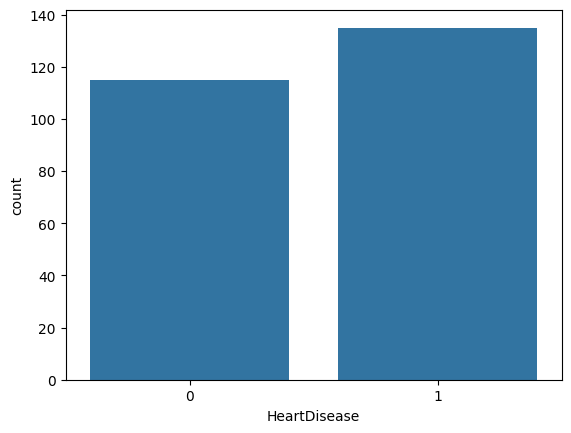

In [20]:
sns.countplot(x='HeartDisease', data=df)
plt.show()